In [1]:
import sys
from pathlib import Path

# Add src/ to the path so swmm_bmi is importable without installing the package.
# Dependencies (pyswmm, bmipy, pyyaml, numpy) must already be in the environment.
sys.path.insert(0, str(Path.cwd() / "src"))

# SWMM BMI Wrapper — Demo Notebook

This notebook tests the `SwmmBmi` wrapper, which exposes EPA SWMM5 (via `pyswmm`) through the
[Basic Model Interface (BMI)](https://bmi.readthedocs.io/) so it can be used inside
[eWaterCycle](https://ewatercycle.readthedocs.io/) or run standalone.

The implementation lives in `src/swmm_bmi/swmm_bmi.py`.

**Example model** (`example_model.inp`): a simple urban catchment with
two subcatchments draining via two junctions to an outfall, driven by a 6-hour triangular storm.

**NOTE** This is just a testing notebook, for working with eWaterCycle go [here](https://github.com/eWaterCycle/ewatercycle-swmm/blob/main/docs/bellinge_example/SWMM_Bellinge_example.ipynb).

In [2]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from swmm_bmi import SwmmBmi

CONFIG_FILE = "example_config.json"

## 1. Initialize the BMI

The config file is a YAML file that points to the SWMM `.inp` file.
All model parameters and timing come from the `.inp` file.

In [3]:
model = SwmmBmi()
model.initialize(CONFIG_FILE)
print("Initialized:", model.get_component_name())

Initialized: SWMM


## 2. Inspect BMI Metadata

### 2a. Time information

In [4]:
start  = model.get_start_time()
end    = model.get_end_time()
dt     = model.get_time_step()
units  = model.get_time_units()

start_dt = datetime.datetime.fromtimestamp(start, tz=datetime.timezone.utc)
end_dt   = datetime.datetime.fromtimestamp(end,   tz=datetime.timezone.utc)

print(f"Time units : {units}")
print(f"Start      : {start_dt.isoformat()}")
print(f"End        : {end_dt.isoformat()}")
print(f"Time step  : {dt:.0f} s  ({dt/60:.1f} min)")
print(f"Total steps: {int((end - start) / dt)}")

Time units : seconds since 1970-01-01 00:00:00.0 +0000
Start      : 1998-01-01T00:00:00+00:00
End        : 1998-01-02T12:00:00+00:00
Time step  : 60 s  (1.0 min)
Total steps: 2160


### 2b. Variable metadata

In [5]:
print(f"{'Variable':<30} {'grid':>5} {'n':>4} {'units':<15} {'type':<10} {'nbytes':>7}")
print("-" * 75)

print("Output variables:")
for var in model.get_output_var_names():
    grid   = model.get_var_grid(var)
    n      = model.get_grid_size(grid)
    units  = model.get_var_units(var)
    dtype  = model.get_var_type(var)
    nbytes = model.get_var_nbytes(var)
    print(f"  {var:<28} {grid:>5} {n:>4} {units:<15} {dtype:<10} {nbytes:>7}")

print("\nInput variables (settable):")
for var in model.get_input_var_names():
    grid  = model.get_var_grid(var)
    n     = model.get_grid_size(grid)
    units = model.get_var_units(var)
    print(f"  {var:<28} {grid:>5} {n:>4} {units}")

Variable                        grid    n units           type        nbytes
---------------------------------------------------------------------------
Output variables:
  subcatchment_runoff              0    8 m3 s-1          float64         64
  node_depth                       1   14 m               float64        112
  node_flooding                    1   14 m3 s-1          float64        112
  link_flow                        2   13 m3 s-1          float64        104
  precipitation                    3    1 in hr-1         float64          8

Input variables (settable):
  node_lateral_inflow              1   14 m3 s-1
  precipitation                    3    1 in hr-1


### 2c. Grid metadata

The wrapper uses three grids:
- Grid 0 — subcatchments
- Grid 1 — nodes (junctions + outfalls)
- Grid 2 — links (conduits)

In [6]:
grid_labels = {0: "subcatchments", 1: "nodes", 2: "links", 3:"raingauges"}

for gid, label in grid_labels.items():
    n     = model.get_grid_size(gid)
    gtype = model.get_grid_type(gid)
    rank  = model.get_grid_rank(gid)
    x = np.empty(n)
    y = np.empty(n)
    model.get_grid_x(gid, x)
    model.get_grid_y(gid, y)
    print(f"Grid {gid} ({label}): type='{gtype}', rank={rank}, size={n}")
    for i in range(n):
        print(f"  element {i}: x={x[i]:.1f}, y={y[i]:.1f}")
    print()

Grid 0 (subcatchments): type='points', rank=2, size=8
  element 0: x=0.0, y=0.0
  element 1: x=0.0, y=0.0
  element 2: x=0.0, y=0.0
  element 3: x=0.0, y=0.0
  element 4: x=0.0, y=0.0
  element 5: x=0.0, y=0.0
  element 6: x=0.0, y=0.0
  element 7: x=0.0, y=0.0

Grid 1 (nodes): type='points', rank=2, size=14
  element 0: x=0.0, y=0.0
  element 1: x=0.0, y=0.0
  element 2: x=0.0, y=0.0
  element 3: x=0.0, y=0.0
  element 4: x=0.0, y=0.0
  element 5: x=0.0, y=0.0
  element 6: x=0.0, y=0.0
  element 7: x=0.0, y=0.0
  element 8: x=0.0, y=0.0
  element 9: x=0.0, y=0.0
  element 10: x=0.0, y=0.0
  element 11: x=0.0, y=0.0
  element 12: x=0.0, y=0.0
  element 13: x=0.0, y=0.0

Grid 2 (links): type='points', rank=2, size=13
  element 0: x=0.0, y=0.0
  element 1: x=0.0, y=0.0
  element 2: x=0.0, y=0.0
  element 3: x=0.0, y=0.0
  element 4: x=0.0, y=0.0
  element 5: x=0.0, y=0.0
  element 6: x=0.0, y=0.0
  element 7: x=0.0, y=0.0
  element 8: x=0.0, y=0.0
  element 9: x=0.0, y=0.0
  element 10: 

## 3. Run the Simulation

Step through the full simulation collecting all output variables at each timestep.

In [7]:
n_sc    = model.get_grid_size(0)
n_nodes = model.get_grid_size(1)
n_links = model.get_grid_size(2)

times       = []
sc_runoff   = []
node_depth  = []
node_flood  = []
link_flow   = []

while model.get_current_time() < model.get_end_time():
    model.update()
    times.append(model.get_current_time())
    sc_runoff.append( model.get_value("subcatchment_runoff", np.empty(n_sc)).copy()    )
    node_depth.append(model.get_value("node_depth",          np.empty(n_nodes)).copy() )
    node_flood.append(model.get_value("node_flooding",       np.empty(n_nodes)).copy() )
    link_flow.append( model.get_value("link_flow",           np.empty(n_links)).copy() )

model.finalize()
print(f"Simulation complete — {len(times)} timesteps collected.")

# Convert to arrays and a pandas time axis
hr         = pd.to_datetime([datetime.datetime.fromtimestamp(t, tz=datetime.timezone.utc) for t in times])
sc_runoff  = np.array(sc_runoff)   # shape: (n_steps, n_sc)
node_depth = np.array(node_depth)  # shape: (n_steps, n_nodes)
node_flood = np.array(node_flood)
link_flow  = np.array(link_flow)   # shape: (n_steps, n_links)

Simulation complete — 2160 timesteps collected.


## 4. Plot Results

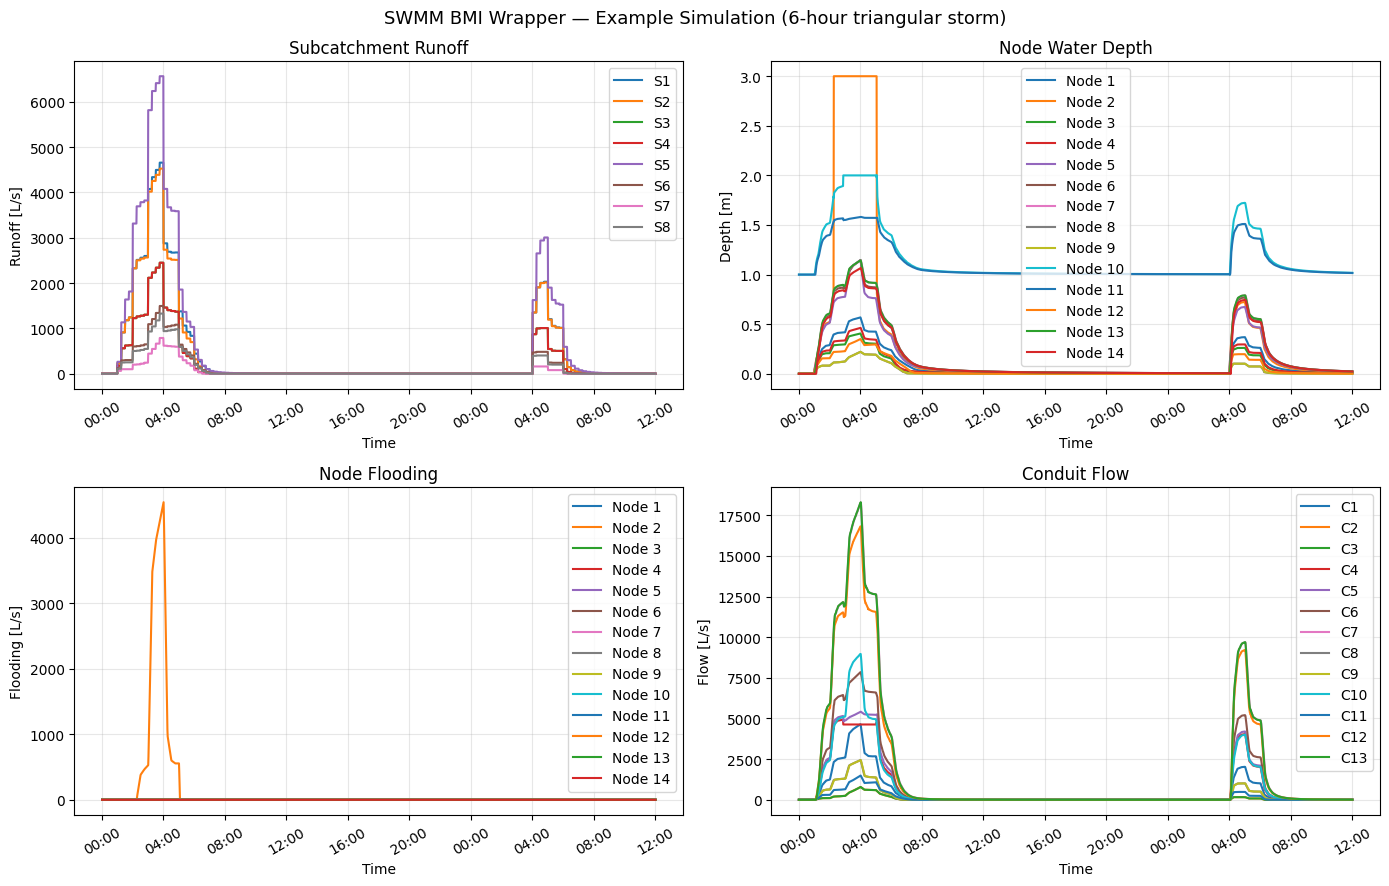

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("SWMM BMI Wrapper — Example Simulation (6-hour triangular storm)", fontsize=13)

sc_labels   = [f"S{i+1}" for i in range(n_sc)]
node_labels = [f"Node {i+1}" for i in range(n_nodes)]
link_labels = [f"C{i+1}" for i in range(n_links)]

# Subcatchment runoff  [m3/s → L/s for readability]
ax = axes[0, 0]
for i, lbl in enumerate(sc_labels):
    ax.plot(hr, sc_runoff[:, i] * 1000, label=lbl)
ax.set_ylabel("Runoff [L/s]")
ax.set_title("Subcatchment Runoff")
ax.legend()

# Node water depth
ax = axes[0, 1]
for i, lbl in enumerate(node_labels):
    ax.plot(hr, node_depth[:, i], label=lbl)
ax.set_ylabel("Depth [m]")
ax.set_title("Node Water Depth")
ax.legend()

# Node flooding
ax = axes[1, 0]
for i, lbl in enumerate(node_labels):
    ax.plot(hr, node_flood[:, i] * 1000, label=lbl)
ax.set_ylabel("Flooding [L/s]")
ax.set_title("Node Flooding")
ax.legend()

# Link flow
ax = axes[1, 1]
for i, lbl in enumerate(link_labels):
    ax.plot(hr, link_flow[:, i] * 1000, label=lbl)
ax.set_ylabel("Flow [L/s]")
ax.set_title("Conduit Flow")
ax.legend()

for ax in axes.flat:
    ax.set_xlabel("Time")
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
# plt.savefig("swmm_bmi_results.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. Verify BMI Correctness

Quick sanity checks on the results.

In [9]:
# All outputs should be non-negative
assert np.all(sc_runoff  >= 0), "Negative runoff values"
assert np.all(node_depth >= 0), "Negative node depths"
assert np.all(node_flood >= 0), "Negative flooding"
# assert np.all(link_flow  >= 0), "Negative link flows"

# Peak runoff should occur after peak rainfall (2:30 = step 30 of 72)
peak_rain_step = 30
peak_runoff_step = np.argmax(sc_runoff[:, 0])
assert peak_runoff_step >= peak_rain_step, (
    f"Runoff peaked before rainfall peak (step {peak_runoff_step} < {peak_rain_step})"
)

# Downstream conduit (C2) flow should lag upstream (C1)
peak_C1 = np.argmax(link_flow[:, 0])
peak_C2 = np.argmax(link_flow[:, 1])
assert peak_C2 >= peak_C1, f"C2 peaked before C1 (step {peak_C2} < {peak_C1})"

print(f"Peak subcatchment S1 runoff : {sc_runoff[:, 0].max()*1000:.2f} L/s at step {peak_runoff_step}")
print(f"Peak C1 flow                : {link_flow[:, 0].max()*1000:.2f} L/s at step {peak_C1}")
print(f"Peak C2 flow                : {link_flow[:, 1].max()*1000:.2f} L/s at step {peak_C2}")
print(f"Max node depth (Node 1)     : {node_depth[:, 0].max():.3f} m")
print("\nAll sanity checks passed.")

Peak subcatchment S1 runoff : 4656.20 L/s at step 225
Peak C1 flow                : 4649.34 L/s at step 240
Peak C2 flow                : 786.11 L/s at step 240
Max node depth (Node 1)     : 0.568 m

All sanity checks passed.


## 6. External Forcing via `set_value("node_lateral_inflow", ...)`

In an eWaterCycle coupling, pre-computed runoff can be injected at each node each
timestep using `set_value("node_lateral_inflow", values)`.

Internally this calls pyswmm's `Node.generated_inflow(rate)`, which:
- accepts flow in **m3/s**
- holds the value constant until the next call
- works like any SWMM lateral inflow with no continuity errors

The cell below injects a constant 10 L/s (0.01 m3/s) at every node for 6 hours
and compares against the built-in triangular-storm run.

In [10]:
EXTERNAL_INFLOW_M3S = 0.05  # 50 L/s injected at every node (on top of storm runoff)

model2 = SwmmBmi()
model2.initialize(CONFIG_FILE)

n_nodes2 = model2.get_grid_size(1)
n_links2 = model2.get_grid_size(2)
times2      = []
node_depth2 = []
node_flood2 = []
link_flow2  = []

while model2.get_current_time() < model2.get_end_time():
    model2.set_value(
        "node_lateral_inflow",
        np.full(n_nodes2, EXTERNAL_INFLOW_M3S)
    )
    model2.update()
    times2.append(model2.get_current_time())
    node_depth2.append(model2.get_value("node_depth",    np.empty(n_nodes2)).copy())
    node_flood2.append(model2.get_value("node_flooding", np.empty(n_nodes2)).copy())
    link_flow2.append( model2.get_value("link_flow",     np.empty(n_links2)).copy())

model2.finalize()

node_depth2 = np.array(node_depth2)
node_flood2 = np.array(node_flood2)
link_flow2  = np.array(link_flow2)
hr2 = pd.to_datetime([datetime.datetime.fromtimestamp(t, tz=datetime.timezone.utc) for t in times2])

print("External inflow run complete.")
print(f"Peak outfall flow (built-in) : {link_flow[:, -1].max()*1000:.1f} L/s")
print(f"Peak outfall flow (+ inflow) : {link_flow2[:, -1].max()*1000:.1f} L/s")

External inflow run complete.
Peak outfall flow (built-in) : 18304.5 L/s
Peak outfall flow (+ inflow) : 18784.2 L/s


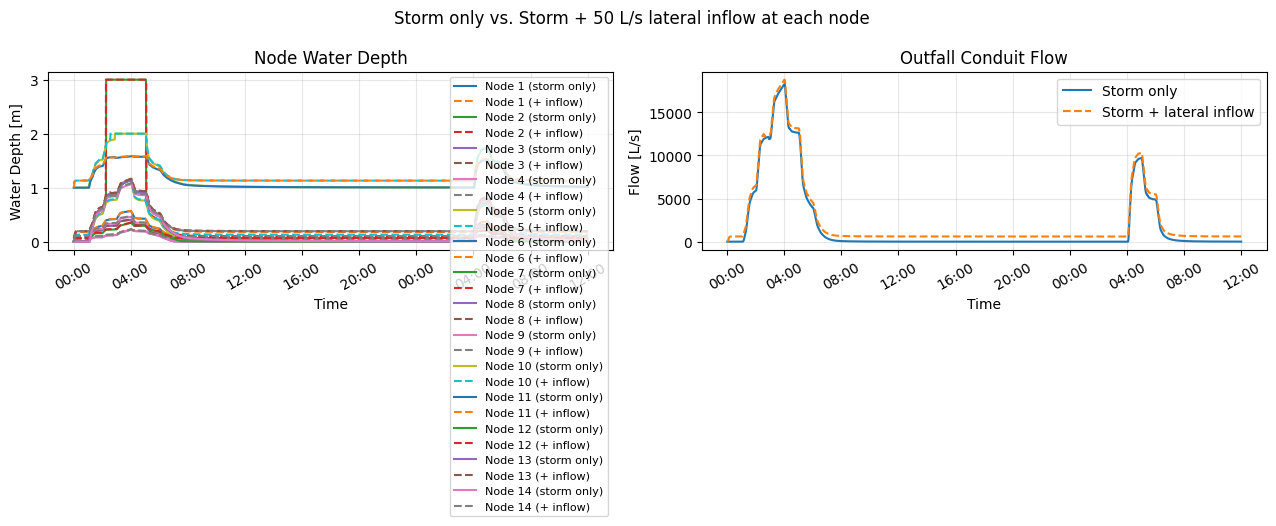

In [11]:
# Compare hydraulic response: built-in storm vs storm + constant node inflow
# sc_runoff is identical in both runs (same .inp timeseries) so is not shown.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    f"Storm only vs. Storm + {EXTERNAL_INFLOW_M3S*1000:.0f} L/s lateral inflow at each node",
    fontsize=12
)

ax = axes[0]
for i, lbl in enumerate(node_labels):
    ax.plot(hr,  node_depth[:, i],      label=f"{lbl} (storm only)")
    ax.plot(hr2, node_depth2[:, i], ls="--", label=f"{lbl} (+ inflow)")
ax.set_ylabel("Water Depth [m]")
ax.set_title("Node Water Depth")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlabel("Time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
ax.plot(hr,  link_flow[:, -1]  * 1000, label="Storm only")
ax.plot(hr2, link_flow2[:, -1] * 1000, label="Storm + lateral inflow", ls="--")
ax.set_ylabel("Flow [L/s]")
ax.set_title("Outfall Conduit Flow")
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlabel("Time")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()